<a href="https://colab.research.google.com/github/karna-charan/-Neural-Networks-and-Deep-Learning-/blob/main/future_air_temperat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

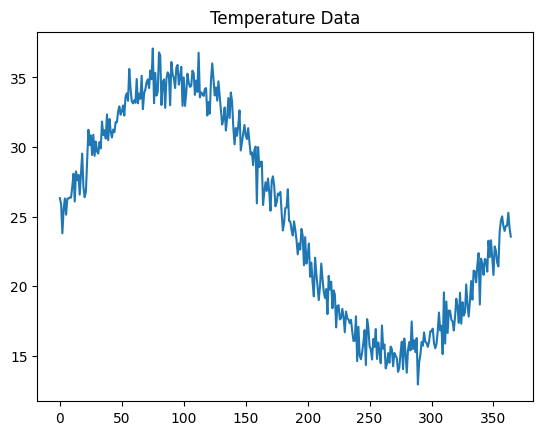

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.1337 - val_loss: 0.0187
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0150 - val_loss: 0.0044
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0070 - val_loss: 0.0024
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0044 - val_loss: 0.0029
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0033 - val_loss: 0.0037
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0033 - val_loss: 0.0037
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 8/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0031 - val_loss: 0.0040
Epoch 9/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0034 - val_loss: 0.0042
Epoch 10/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0030 - val_loss: 0.0042
Epoch 11/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0034 - val_loss: 0.0046
Epoch 12/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0033 - val_l

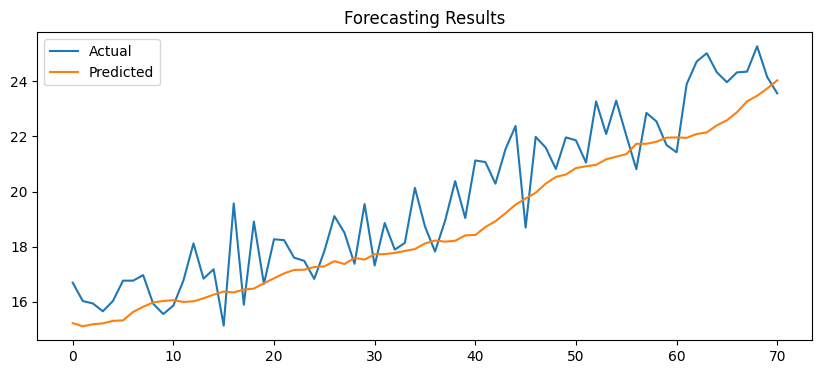

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Today's Temp: 23.57
Tomorrow Prediction: 24.29


In [1]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Step 2: Generate synthetic temperature data
np.random.seed(10)
days = 365
t = np.arange(days)

temp = 25 + 10*np.sin(2*np.pi*t/365) + np.random.normal(0, 1, days)

plt.plot(temp)
plt.title("Temperature Data")
plt.show()

# Step 3: Normalize using MinMaxScaler
scaler = MinMaxScaler()
temp_scaled = scaler.fit_transform(temp.reshape(-1,1))

# Step 4: Create sequences
def create_sequences(data, step=10):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_sequences(temp_scaled, time_step)

# Step 5: Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Step 6: Build Stacked LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.2),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Step 7: Train model
history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=16,
                    validation_data=(X_test, y_test),
                    verbose=1)

# Step 8: Predictions
pred_scaled = model.predict(X_test)

# Convert back to original scale
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test)

# Step 9: Evaluation
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

# Step 10: Plot results
plt.figure(figsize=(10,4))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Forecasting Results")
plt.show()

# Step 11: Predict next day
last_seq = temp_scaled[-time_step:].reshape(1, time_step, 1)
future_scaled = model.predict(last_seq)
future = scaler.inverse_transform(future_scaled)

print("Today's Temp:", round(temp[-1],2))
print("Tomorrow Prediction:", round(future[0][0],2))